# Bivariate Analysis & Transformations — is the relationship really a straight line?

01 Core Python · 02 Pandas · 03 Cleaning · 04 Transformation · 05 Feature Engineering · **▶ 06 Regression** · 07 Model Prep · 08 Case Studies

`06_Statistics_and_Regression/01_bivariate_analysis_and_transformations.ipynb`

---

### In one paragraph (no jargon)

Before fitting any model, look at two variables together and ask one question: **is this a straight line?** Linear regression assumes it is, and if it isn't, the model will be confidently wrong. The good news is that many curved relationships become straight after a simple transformation — take the log of one variable and a curve flattens into exactly the line the model wants. This notebook covers measuring the relationship (correlation), seeing it (scatter plots), and fixing it (transformations).

### After this notebook you can

- Measure association with Pearson and Spearman correlation, and know when they disagree
- Read a scatter plot for curvature, spread and outliers before fitting anything
- Apply log, square-root and reciprocal transforms to straighten a curved relationship
- Show that a transformation actually improved the fit rather than assuming it did

**Assumed knowledge:** `02_Pandas_Essentials` and basic descriptive statistics

### What's inside

1. Setup
2. Making a relationship you can see
3. Correlation — two kinds
4. Why correlation alone will mislead you
5. Straightening a curve with a transform
6. Choosing the right transform
7. Exam quick-reference

---

> **▶ Runs on its own.** The next cell is the only setup you need. It imports the
> libraries and loads the data. If the `datasets/` folder isn't where it expects,
> it rebuilds an equivalent dataset in memory so **every cell below still runs** —
> handy if you copy this single `.ipynb` somewhere else.
>
> **▶ Reading the cells.** Code comments explain *what the line does*; the text
> blocks explain *why you'd do it*. Look for these markers:
> `# WHAT:` a plain-English translation · `# WHY:` the reason it matters ·
> `# 🔧 CHANGE THIS:` the knob to turn when the exam question differs ·
> **⚡ Beyond the syllabus** = optional, higher-mark techniques.

### Jargon buster

| Term | Plain English |
|---|---|
| **Dependent variable (y)** | The thing you're trying to predict or explain. Sales, price, mpg. |
| **Independent variable (X)** | The things you're using to predict it. Also called features or predictors. |
| **Coefficient** | "If this predictor goes up by 1, y changes by this much, holding everything else fixed." |
| **Intercept** | The predicted y when every predictor is zero. Often not meaningful on its own. |
| **Residual** | Actual minus predicted. The bit the model got wrong, for one row. |
| **R²** | The share of the variation in y the model explains. 0 = none, 1 = all. |
| **p-value** | "If this predictor really had no effect, how likely is a result this strong by chance?" Below 0.05 is the usual threshold for taking it seriously. |
| **Homoscedasticity** | The errors are equally spread across the whole range. The opposite is heteroscedasticity. |
| **Autocorrelation** | Today's error is related to yesterday's — common in time series, a problem for the standard formulas. |
| **Multicollinearity** | Two predictors carry nearly the same information, so the model can't tell which deserves the credit. |
| **VIF** | Variance Inflation Factor — the standard multicollinearity score. Above 5 is a warning; above 10 is a problem. |
| **OLS** | Ordinary Least Squares — the standard way of fitting a straight line by minimising squared errors. |

In [1]:
# =============================================================================
# SETUP — run this cell first. It is the only cell with dependencies.
# =============================================================================
# WHAT: `import` pulls in code other people have written so we don't rewrite it.
#       The `as pd` part is a nickname, so we can type `pd` instead of `pandas`.
import pandas as pd          # tables of data (think: Excel, but programmable)
import numpy as np           # fast maths on whole columns at once
import matplotlib.pyplot as plt   # charts
import warnings

warnings.filterwarnings('ignore')          # hide version-upgrade notices, keeps output readable
pd.set_option('display.max_columns', 50)   # don't hide columns behind "..."
pd.set_option('display.width', 160)
import os
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
sns.set_theme(style="whitegrid")

def find_datasets_folder(start=None):
    """Walk upwards from this notebook looking for the shared `datasets/` folder.

    WHY: it means the notebook works whether you opened it from its own folder,
    from the top of the notes, or from anywhere else on your machine.
    """
    here = os.path.abspath(start or os.getcwd())
    for _ in range(6):                       # look up to 6 folders up
        candidate = os.path.join(here, 'datasets')
        if os.path.isdir(candidate):
            return candidate
        parent = os.path.dirname(here)
        if parent == here:
            break
        here = parent
    return None

def dataset_path(filename, rebuild=None):
    """Return a real path to `filename`, materialising a temp copy if it's missing.

    WHY: a few pandas tools (pd.ExcelFile, pd.read_sql) need an actual file path
         rather than a DataFrame, so the fallback has to be written to disk.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            return path
    if rebuild is None:
        raise FileNotFoundError(filename)
    import tempfile
    tmp = os.path.join(tempfile.mkdtemp(prefix='bda_'), filename)
    frame = rebuild()
    (frame.to_excel(tmp, index=False) if filename.lower().endswith(('.xlsx', '.xls'))
     else frame.to_csv(tmp, index=False))
    print(f"'{filename}' not found -> wrote a rebuilt copy to {tmp}")
    return tmp

def load_data(filename, rebuild=None, **read_kwargs):
    """Load `filename` from the shared datasets folder, or rebuild it in memory.

    WHAT: tries to read the real file; if it can't find it, calls `rebuild()`
          which recreates a dataset with the same columns and behaviour.
    WHY:  guarantees this notebook runs even if the CSV goes missing.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            reader = pd.read_excel if filename.lower().endswith(('.xlsx', '.xls')) else pd.read_csv
            print(f"Loaded '{filename}' from {folder}")
            return reader(path, **read_kwargs)
    if rebuild is None:
        raise FileNotFoundError(f"Could not find {filename} and no fallback was supplied.")
    print(f"'{filename}' not found on disk -> rebuilding an equivalent dataset in memory.")
    built = rebuild()
    if 'chunksize' in read_kwargs:            # keep chunked reads working on the fallback path
        size = read_kwargs['chunksize']
        return (built.iloc[i:i + size] for i in range(0, len(built), size))
    return built

print("Setup complete. pandas", pd.__version__, "| numpy", np.__version__)

Setup complete. pandas 3.0.2 | numpy 2.4.4


## 1. Making a relationship you can see

We'll build a dataset where the true relationship is **logarithmic**: sales rise steeply with early
advertising spend, then flatten out as the market saturates. This is a genuinely common shape in business —
diminishing returns. A straight-line model will fit it badly in a very specific and recognisable way.

       Advertising_Spend    Sales
count            1000.00  1000.00
mean              497.68    88.86
std               291.29    10.15
min                 2.23    36.87
25%               241.02    84.11
50%               495.33    92.00
75%               759.13    96.08
max               999.11   103.53


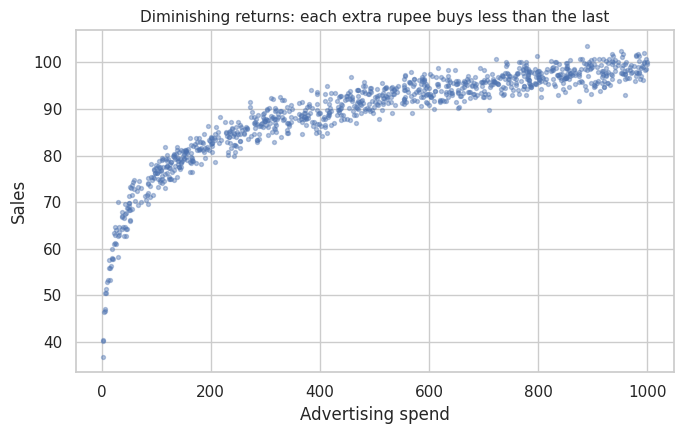

Look at the shape: steep at first, then flattening. That is NOT a straight line.


In [2]:
rng = np.random.default_rng(42)
n = 1000

# TRUE relationship: sales = 30 + 10 * ln(spend) + noise  -> a curve, not a line
advertising_spend = rng.uniform(1, 1000, n)
sales = 30 + 10 * np.log(advertising_spend) + rng.normal(0, 2, n)

data = pd.DataFrame({'Advertising_Spend': advertising_spend, 'Sales': sales})
print(data.describe().round(2))

plt.figure(figsize=(7, 4.5))
plt.scatter(data['Advertising_Spend'], data['Sales'], s=8, alpha=.4)
plt.xlabel('Advertising spend'); plt.ylabel('Sales')
plt.title('Diminishing returns: each extra rupee buys less than the last', fontsize=11)
plt.tight_layout(); plt.show()
print("Look at the shape: steep at first, then flattening. That is NOT a straight line.")

## 2. Correlation — two kinds, and why the difference matters

- **Pearson** measures how close the points are to a **straight line**. It is the default `.corr()`.
- **Spearman** ranks the values first, then correlates the ranks. It measures whether y consistently
  **increases** with x, straight or not.

If Spearman is much higher than Pearson, the relationship is **monotonic but curved** — which is precisely
the signal that a transformation will help. That one comparison is a genuinely useful diagnostic and it takes
two lines.

In [3]:
pearson_r, pearson_p = stats.pearsonr(data['Advertising_Spend'], data['Sales'])
spearman_r, spearman_p = stats.spearmanr(data['Advertising_Spend'], data['Sales'])

print(f"Pearson  r = {pearson_r:+.4f}   (p = {pearson_p:.2e})   <- how straight-line is it?")
print(f"Spearman r = {spearman_r:+.4f}   (p = {spearman_p:.2e})   <- how consistently increasing is it?")
print(f"\nGap = {spearman_r - pearson_r:+.4f}")
print("""
INTERPRETING THE GAP
  Spearman >> Pearson  ->  strong relationship, but curved. Try a transformation.
  Pearson  ~ Spearman  ->  the relationship is close to linear already.
  Pearson  >> Spearman ->  unusual; normally means one or two outliers are creating
                           an apparent straight line that the ranks don't support.""")

print("\nStrength scale for either coefficient:")
print("  0.00-0.19 negligible | 0.20-0.39 weak | 0.40-0.59 moderate | 0.60-0.79 strong | 0.80-1.00 very strong")

Pearson  r = +0.8649   (p = 6.20e-301)   <- how straight-line is it?
Spearman r = +0.9466   (p = 0.00e+00)   <- how consistently increasing is it?

Gap = +0.0817

INTERPRETING THE GAP
  Spearman >> Pearson  ->  strong relationship, but curved. Try a transformation.
  Pearson  ~ Spearman  ->  the relationship is close to linear already.
  Pearson  >> Spearman ->  unusual; normally means one or two outliers are creating
                           an apparent straight line that the ranks don't support.

Strength scale for either coefficient:
  0.00-0.19 negligible | 0.20-0.39 weak | 0.40-0.59 moderate | 0.60-0.79 strong | 0.80-1.00 very strong


## 3. Why correlation alone will mislead you

Four datasets can share an identical correlation of 0.816 and look completely different — this is Anscombe's
quartet, and it's the single best argument for plotting your data. **Always plot before you conclude.**

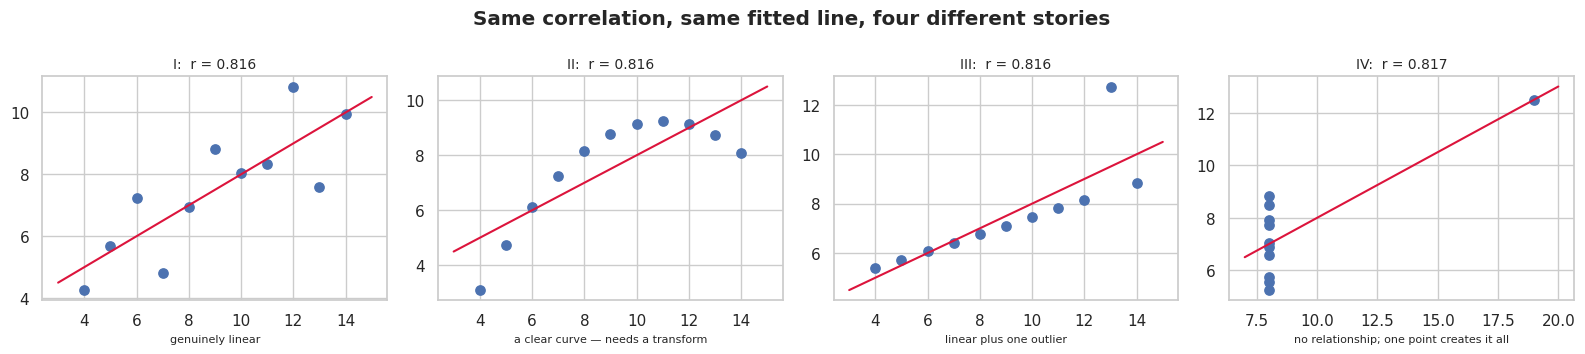

All four have r = 0.816 to three decimals. Only the first one should be modelled with a
straight line. This is why 'I calculated the correlation' is never a complete answer.


In [4]:
# Anscombe's quartet — same r, same means, same regression line, four different realities
anscombe = {
    'I':   ([10,8,13,9,11,14,6,4,12,7,5], [8.04,6.95,7.58,8.81,8.33,9.96,7.24,4.26,10.84,4.82,5.68]),
    'II':  ([10,8,13,9,11,14,6,4,12,7,5], [9.14,8.14,8.74,8.77,9.26,8.10,6.13,3.10,9.13,7.26,4.74]),
    'III': ([10,8,13,9,11,14,6,4,12,7,5], [7.46,6.77,12.74,7.11,7.81,8.84,6.08,5.39,8.15,6.42,5.73]),
    'IV':  ([8,8,8,8,8,8,8,19,8,8,8],     [6.58,5.76,7.71,8.84,8.47,7.04,5.25,12.50,5.56,7.91,6.89]),
}
verdicts = {'I': 'genuinely linear', 'II': 'a clear curve — needs a transform',
            'III': 'linear plus one outlier', 'IV': 'no relationship; one point creates it all'}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, (label, (x, y)) in zip(axes, anscombe.items()):
    r = np.corrcoef(x, y)[0, 1]
    slope, intercept = np.polyfit(x, y, 1)
    ax.scatter(x, y, s=45)
    xs = np.linspace(min(x) - 1, max(x) + 1, 10)
    ax.plot(xs, slope * xs + intercept, color='crimson', lw=1.5)
    ax.set_title(f'{label}:  r = {r:.3f}', fontsize=10)
    ax.set_xlabel(verdicts[label], fontsize=8)
plt.suptitle("Same correlation, same fitted line, four different stories", fontweight='bold')
plt.tight_layout(); plt.show()

print("All four have r = 0.816 to three decimals. Only the first one should be modelled with a")
print("straight line. This is why 'I calculated the correlation' is never a complete answer.")

## 4. Straightening a curve with a transform

If y rises with the **log** of x, then plotting y against `log(x)` turns the curve into a straight line — and
a straight line is exactly what linear regression is built for. Nothing about the data changes; you've just
measured x on a scale that matches the underlying relationship.

R² using raw spend        : 0.7480
R² using log(spend)       : 0.9602
-> the transform explains 21.2 more percentage points of the variation,
   with no new data and no more complex model. That is a very cheap improvement.



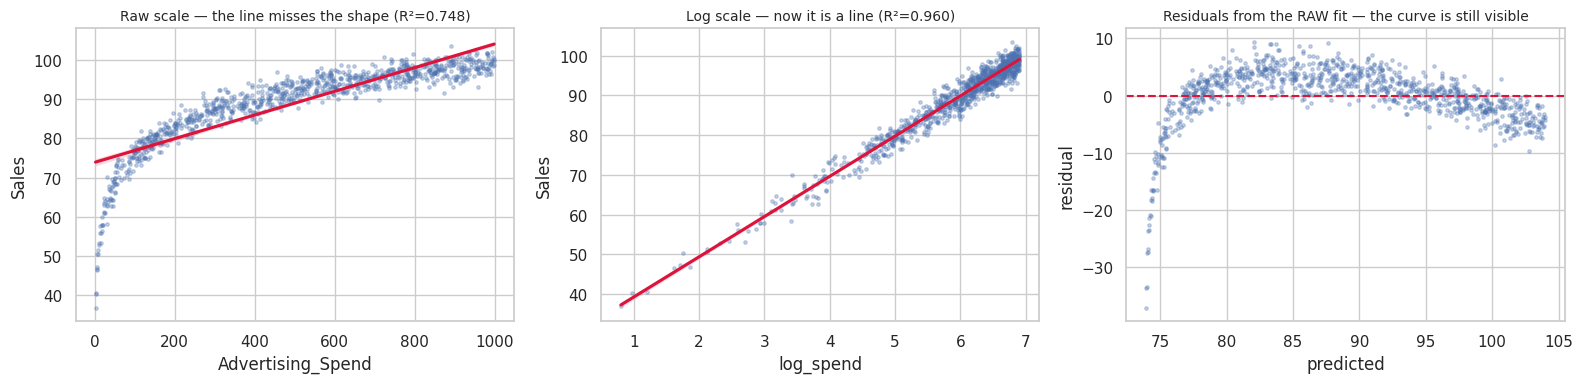

The third panel is the diagnostic to memorise: if the residuals form a pattern (an arch,
a U, a funnel), the model is missing structure. Residuals should look like formless noise.


In [5]:
data['log_spend'] = np.log(data['Advertising_Spend'])

# Fit the same model twice — once on the raw column, once on the logged one
X_raw, X_log, y = data[['Advertising_Spend']], data[['log_spend']], data['Sales']
r2_raw = r2_score(y, LinearRegression().fit(X_raw, y).predict(X_raw))
r2_log = r2_score(y, LinearRegression().fit(X_log, y).predict(X_log))

print(f"R² using raw spend        : {r2_raw:.4f}")
print(f"R² using log(spend)       : {r2_log:.4f}")
print(f"-> the transform explains {(r2_log - r2_raw) * 100:.1f} more percentage points of the variation,")
print("   with no new data and no more complex model. That is a very cheap improvement.\n")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.regplot(x='Advertising_Spend', y='Sales', data=data, ax=axes[0],
            scatter_kws={'s': 6, 'alpha': .3}, line_kws={'color': 'crimson'})
axes[0].set_title(f'Raw scale — the line misses the shape (R²={r2_raw:.3f})', fontsize=10)

sns.regplot(x='log_spend', y='Sales', data=data, ax=axes[1],
            scatter_kws={'s': 6, 'alpha': .3}, line_kws={'color': 'crimson'})
axes[1].set_title(f'Log scale — now it is a line (R²={r2_log:.3f})', fontsize=10)

resid_raw = y - LinearRegression().fit(X_raw, y).predict(X_raw)
axes[2].scatter(LinearRegression().fit(X_raw, y).predict(X_raw), resid_raw, s=6, alpha=.3)
axes[2].axhline(0, color='crimson', ls='--')
axes[2].set_title('Residuals from the RAW fit — the curve is still visible', fontsize=10)
axes[2].set_xlabel('predicted'); axes[2].set_ylabel('residual')
plt.tight_layout(); plt.show()

print("The third panel is the diagnostic to memorise: if the residuals form a pattern (an arch,")
print("a U, a funnel), the model is missing structure. Residuals should look like formless noise.")

## 5. Choosing the right transform

Match the transform to the shape you see. The table below is the practical version; the cell after it tries
all of them and reports which actually won, which is a far stronger answer than picking one and hoping.

In [6]:
candidates = {
    'none (raw x)':      lambda s: s,
    'log(x)':            np.log1p,          # for diminishing returns / right-skewed x
    'sqrt(x)':           np.sqrt,           # milder than log; works on counts
    '1/x (reciprocal)':  lambda s: 1 / s.replace(0, np.nan),   # for sharply decaying curves
    'x squared':         lambda s: s ** 2,  # for accelerating curves
}

print(f"{'TRANSFORM OF X':<22}{'R²':>10}{'PEARSON r':>12}   VERDICT")
print("-" * 68)
results = {}
for label, fn in candidates.items():
    xt = fn(data['Advertising_Spend']).replace([np.inf, -np.inf], np.nan)
    ok = xt.notna()
    Xt, yt = xt[ok].to_frame(), data['Sales'][ok]
    r2 = r2_score(yt, LinearRegression().fit(Xt, yt).predict(Xt))
    r = np.corrcoef(xt[ok], yt)[0, 1]
    results[label] = r2
    print(f"{label:<22}{r2:>10.4f}{r:>12.4f}")

best = max(results, key=results.get)
print(f"\nBest transform: {best}  (R² = {results[best]:.4f})")

print("""
THE PRACTICAL RULE
  Curve flattens out (diminishing returns)     ->  log(x)
  Curve gets steeper (accelerating growth)     ->  x squared, or log(y) instead
  Right-skewed variable, long tail             ->  log or sqrt
  Contains zeros                               ->  log1p(x), never log(x)
  Contains negatives                           ->  Yeo-Johnson, not log
  Sharp early drop then flat                   ->  1/x

ALWAYS SAY WHAT IT COSTS YOU
  After a log transform the coefficient no longer means "one more rupee of spend gives
  this much more in sales". It means "a 1% increase in spend gives roughly this much
  more". Interpretability is the price of the better fit, and stating that trade-off
  is worth as much as the improvement itself.""")

TRANSFORM OF X                R²   PEARSON r   VERDICT
--------------------------------------------------------------------
none (raw x)              0.7480      0.8649
log(x)                    0.9600      0.9798
sqrt(x)                   0.8736      0.9347
1/x (reciprocal)          0.3676     -0.6063
x squared                 0.5612      0.7491

Best transform: log(x)  (R² = 0.9600)

THE PRACTICAL RULE
  Curve flattens out (diminishing returns)     ->  log(x)
  Curve gets steeper (accelerating growth)     ->  x squared, or log(y) instead
  Right-skewed variable, long tail             ->  log or sqrt
  Contains zeros                               ->  log1p(x), never log(x)
  Contains negatives                           ->  Yeo-Johnson, not log
  Sharp early drop then flat                   ->  1/x

ALWAYS SAY WHAT IT COSTS YOU
  After a log transform the coefficient no longer means "one more rupee of spend gives
  this much more in sales". It means "a 1% increase in spend gives roughl

---

## Exam quick-reference

| To do this | Write this |
|---|---|
| Pearson correlation | `df['a'].corr(df['b'])` |
| Whole correlation matrix | `df.corr(numeric_only=True)` |
| Spearman | `df.corr(method='spearman')` |
| With a p-value | `scipy.stats.pearsonr(a, b)` |
| Scatter with a fitted line | `sns.regplot(x=, y=, data=)` |
| All pairs at once | `sns.pairplot(df)` |
| Heatmap | `sns.heatmap(df.corr(numeric_only=True), annot=True)` |
| Log transform | `np.log1p(s)` |
| Square root | `np.sqrt(s)` |
| Measure skew | `scipy.stats.skew(s)` |
| Fit a line | `LinearRegression().fit(X, y)` |
| R² | `r2_score(y, predictions)` |
| Residuals | `y - model.predict(X)` |

### Adapting this in the exam

- 'Examine the relationship between X and Y' → scatter plot, correlation, then one sentence interpreting sign and strength.
- 'Is the relationship linear?' → plot it, then compare Pearson with Spearman.
- 'Transform the variable' → try log first for skewed/flattening data, show the before/after R².
- Every correlation answer needs the caveat sentence: association, not causation, and note the sample size.

### Traps that cost marks

- `.corr()` measures **linear** association only. A perfect U-shape gives r ≈ 0 — the relationship is strong and the number says nothing.
- Correlation is not causation, and it never becomes causation however small the p-value.
- One outlier can create or destroy a correlation. Always plot.
- `np.log(0)` is `-inf`. Use `np.log1p`, or shift the column first.
- A high R² on transformed data isn't comparable to R² on the raw data if you transformed **y** — only comparable if you transformed **x**.
- `.corr()` silently drops text columns. A column missing from the matrix is stored as text — check `df.dtypes`.